In [1]:
# ============================================
# NOTEBOOK 4: xG MODEL TRAINING
# Building and comparing two xG models:
# 1. Logistic Regression — the industry
#    standard baseline for xG modelling
# 2. XGBoost — advanced gradient boosting
#
# We validate against StatsBomb's own xG
# values to test our model quality
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, brier_score_loss,
                             log_loss, roc_curve)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

# Load feature matrix
shots = pd.read_csv('../data/shots_features.csv')

print("Libraries loaded")
print(f"Dataset: {shots.shape[0]} shots, {shots.shape[1]} columns")

Libraries loaded
Dataset: 839 shots, 11 columns


In [2]:
# ============================================
# PREPARE DATA FOR MODELLING
# ============================================

# Define our feature columns
feature_cols = ['distance', 'angle', 'is_header',
                'under_pressure', 'is_open_play']

X = shots[feature_cols]
y = shots['is_goal']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} shots")
print(f"Test set:     {X_test.shape[0]} shots")
print(f"\nTraining goal rate: {y_train.mean():.1%}")
print(f"Test goal rate:     {y_test.mean():.1%}")

# Scale features for Logistic Regression
# (XGBoost doesn't need scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData prepared")

Training set: 671 shots
Test set:     168 shots

Training goal rate: 13.3%
Test goal rate:     13.1%

Data prepared


In [3]:
# ============================================
# MODEL 1: LOGISTIC REGRESSION
# The original xG modelling method
# Directly interpretable coefficients tell
# us exactly how each feature affects
# goal probability
# ============================================

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Get probability predictions
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
lr_auc = roc_auc_score(y_test, lr_probs)
lr_brier = brier_score_loss(y_test, lr_probs)
lr_logloss = log_loss(y_test, lr_probs)

print("LOGISTIC REGRESSION RESULTS:")
print(f"  AUC-ROC:     {lr_auc:.3f}")
print(f"  Brier Score: {lr_brier:.3f}")
print(f"  Log Loss:    {lr_logloss:.3f}")

# Print feature coefficients
print("\nFeature Coefficients:")
print("(negative = reduces xG, positive = increases xG)")
for feat, coef in zip(feature_cols, lr_model.coef_[0]):
    print(f"  {feat:<20} {coef:+.3f}")

LOGISTIC REGRESSION RESULTS:
  AUC-ROC:     0.772
  Brier Score: 0.101
  Log Loss:    0.336

Feature Coefficients:
(negative = reduces xG, positive = increases xG)
  distance             -1.292
  angle                -0.374
  is_header            -0.401
  under_pressure       -0.313
  is_open_play         -0.006


In [4]:
# ============================================
# MODEL 2: XGBOOST
# Captures non-linear relationships
# between features and goal probability
# ============================================

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)

# Get probability predictions
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate
xgb_auc = roc_auc_score(y_test, xgb_probs)
xgb_brier = brier_score_loss(y_test, xgb_probs)
xgb_logloss = log_loss(y_test, xgb_probs)

print("XGBOOST RESULTS:")
print(f"  AUC-ROC:     {xgb_auc:.3f}")
print(f"  Brier Score: {xgb_brier:.3f}")
print(f"  Log Loss:    {xgb_logloss:.3f}")

XGBOOST RESULTS:
  AUC-ROC:     0.711
  Brier Score: 0.109
  Log Loss:    0.380


In [5]:
# ============================================
# VALIDATION — COMPARE AGAINST STATSBOMB xG
# StatsBomb provides their own xG values
# We compare our model predictions against
# theirs to validate quality
# ============================================

# Get StatsBomb xG for test set
sb_xg_test = shots.iloc[X_test.index]['shot_statsbomb_xg']

# StatsBomb xG performance
sb_auc = roc_auc_score(y_test, sb_xg_test)
sb_brier = brier_score_loss(y_test, sb_xg_test)

print("=" * 50)
print(f"{'Model':<25} {'AUC':>8} {'Brier':>8}")
print("=" * 50)
print(f"{'Logistic Regression':<25} {lr_auc:>8.3f} {lr_brier:>8.3f}")
print(f"{'XGBoost':<25} {xgb_auc:>8.3f} {xgb_brier:>8.3f}")
print(f"{'StatsBomb (baseline)':<25} {sb_auc:>8.3f} {sb_brier:>8.3f}")
print("=" * 50)

print(f"\nOur best model vs StatsBomb:")
print(f"AUC gap: {sb_auc - lr_auc:.3f}")
print(f"\nThis gap exists because StatsBomb uses")
print(f"additional features like goalkeeper position,")
print(f"defensive shape, and body angle that we")
print(f"don't have access to in the open dataset.")

Model                          AUC    Brier
Logistic Regression          0.772    0.101
XGBoost                      0.711    0.109
StatsBomb (baseline)         0.825    0.094

Our best model vs StatsBomb:
AUC gap: 0.053

This gap exists because StatsBomb uses
additional features like goalkeeper position,
defensive shape, and body angle that we
don't have access to in the open dataset.


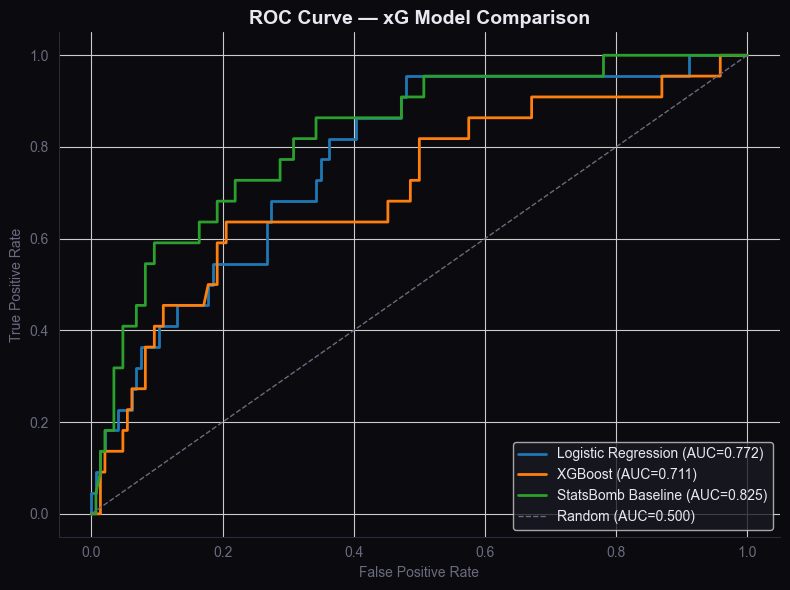

ROC curve saved


In [6]:
# ============================================
# ROC CURVE — VISUAL COMPARISON
# ============================================

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0a0a0f')
ax.set_facecolor('#0a0a0f')

# Plot all three curves
for probs, label, color in [
    (lr_probs, f'Logistic Regression (AUC={lr_auc:.3f})', '#00e5a0'),
    (xgb_probs, f'XGBoost (AUC={xgb_auc:.3f})', '#7b61ff'),
    (sb_xg_test, f'StatsBomb Baseline (AUC={sb_auc:.3f})', '#ffd166')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, label=label, linewidth=2)

# Random classifier baseline
ax.plot([0,1], [0,1], '--', color='#6b6b80',
        label='Random (AUC=0.500)', linewidth=1)

ax.set_title('ROC Curve — xG Model Comparison',
             color='#e8e8f0', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', color='#6b6b80')
ax.set_ylabel('True Positive Rate', color='#6b6b80')
ax.tick_params(colors='#6b6b80')
ax.spines['bottom'].set_color('#2a2a3a')
ax.spines['left'].set_color('#2a2a3a')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(facecolor='#1a1a24', labelcolor='#e8e8f0', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/roc_curve_xg.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("ROC curve saved")